In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.keras.datasets import mnist
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

## PROBLEM 1: tSNE dim reduction

### part A

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


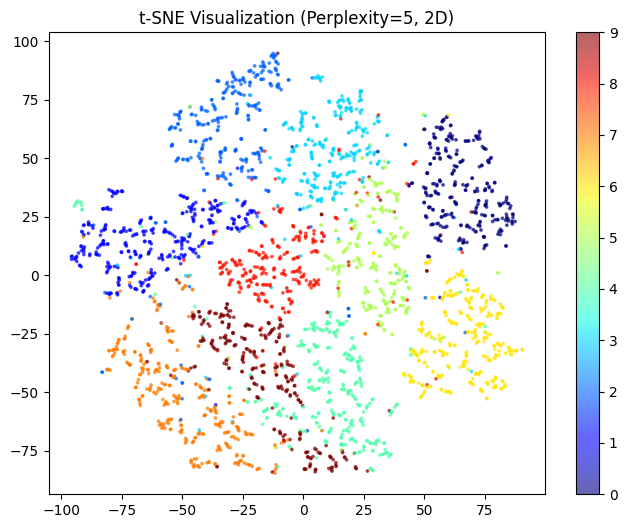

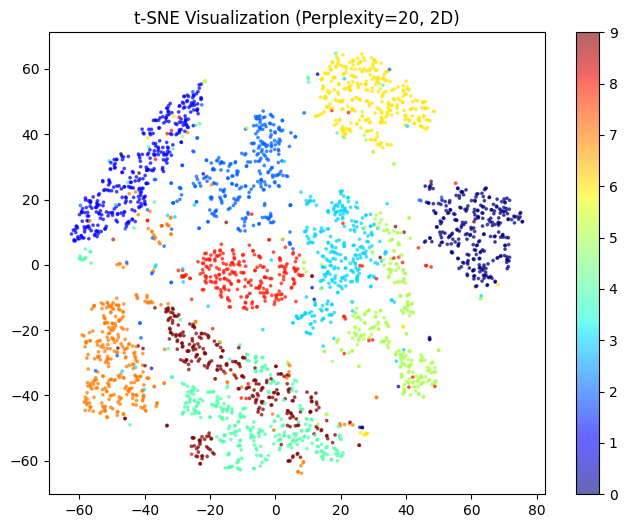

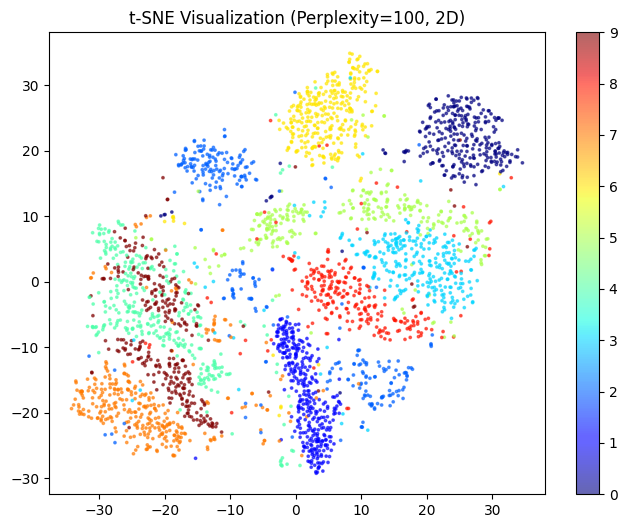

<Figure size 800x600 with 0 Axes>

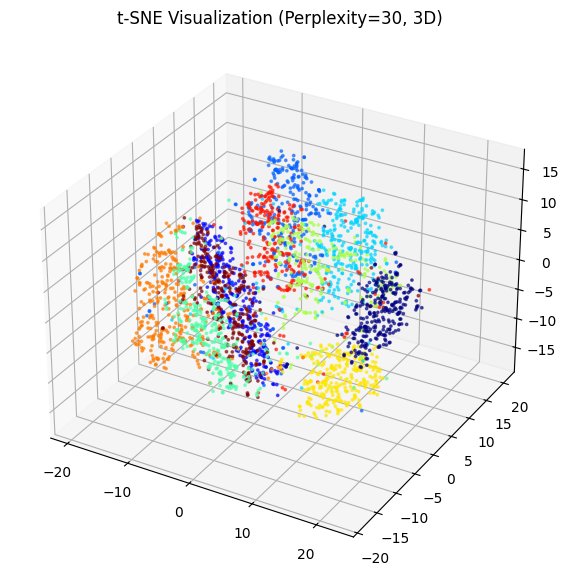

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (_, _) = mnist.load_data()

# Flatten the images to 1D vectors (28x28 -> 784)
x_train = x_train.reshape(-1, 28 * 28).astype(np.float32) / 255.0  # Normalize

# Sample 3000 images for faster computation
num_samples = 3000
x_sample = x_train[:num_samples]
y_sample = y_train[:num_samples]

# Function to apply t-SNE and visualize results
def plot_tsne(perplexity, dim=2):
    tsne = TSNE(n_components=dim, perplexity=perplexity, random_state=42)
    tsne_results = tsne.fit_transform(x_sample)

    plt.figure(figsize=(8, 6))
    if dim == 2:
        plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_sample, cmap='jet', alpha=0.6, s = 3)
        plt.colorbar()
        plt.title(f"t-SNE Visualization (Perplexity={perplexity}, 2D)")
    elif dim == 3:
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2], c=y_sample, cmap='jet', alpha=0.6, s = 3)
        ax.set_title(f"t-SNE Visualization (Perplexity={perplexity}, 3D)")
    plt.show()

# Try different perplexity values
for perp in [5, 20, 100]:
    plot_tsne(perp, dim=2)

# Plot in 3D for one perplexity value
plot_tsne(30, dim=3)

### part B

Running DBSCAN on 2D t-SNE representation


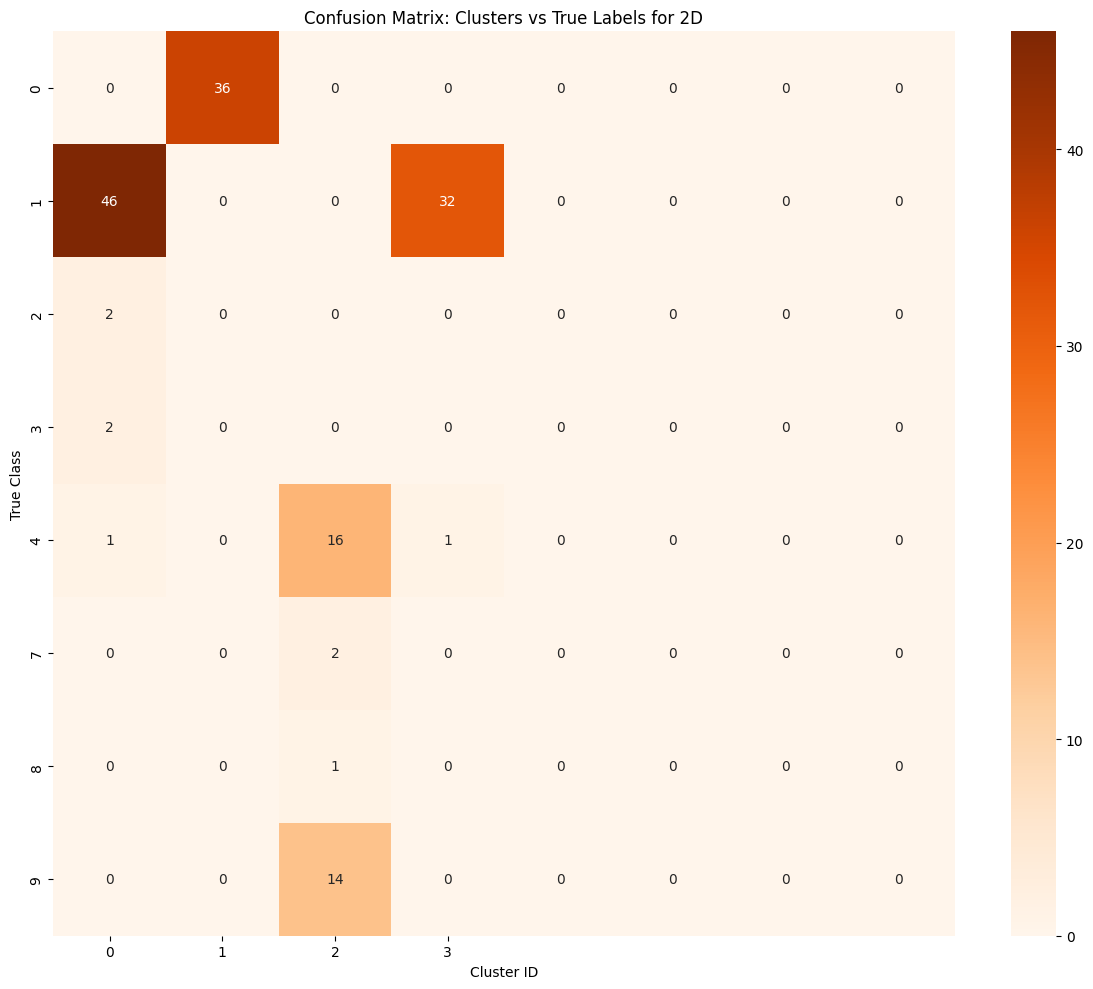

Adjusted Rand Index: 0.570
Normalized Mutual Info: 0.714
Number of clusters: 4
Noise points: 847
Running DBSCAN on 3D t-SNE representation


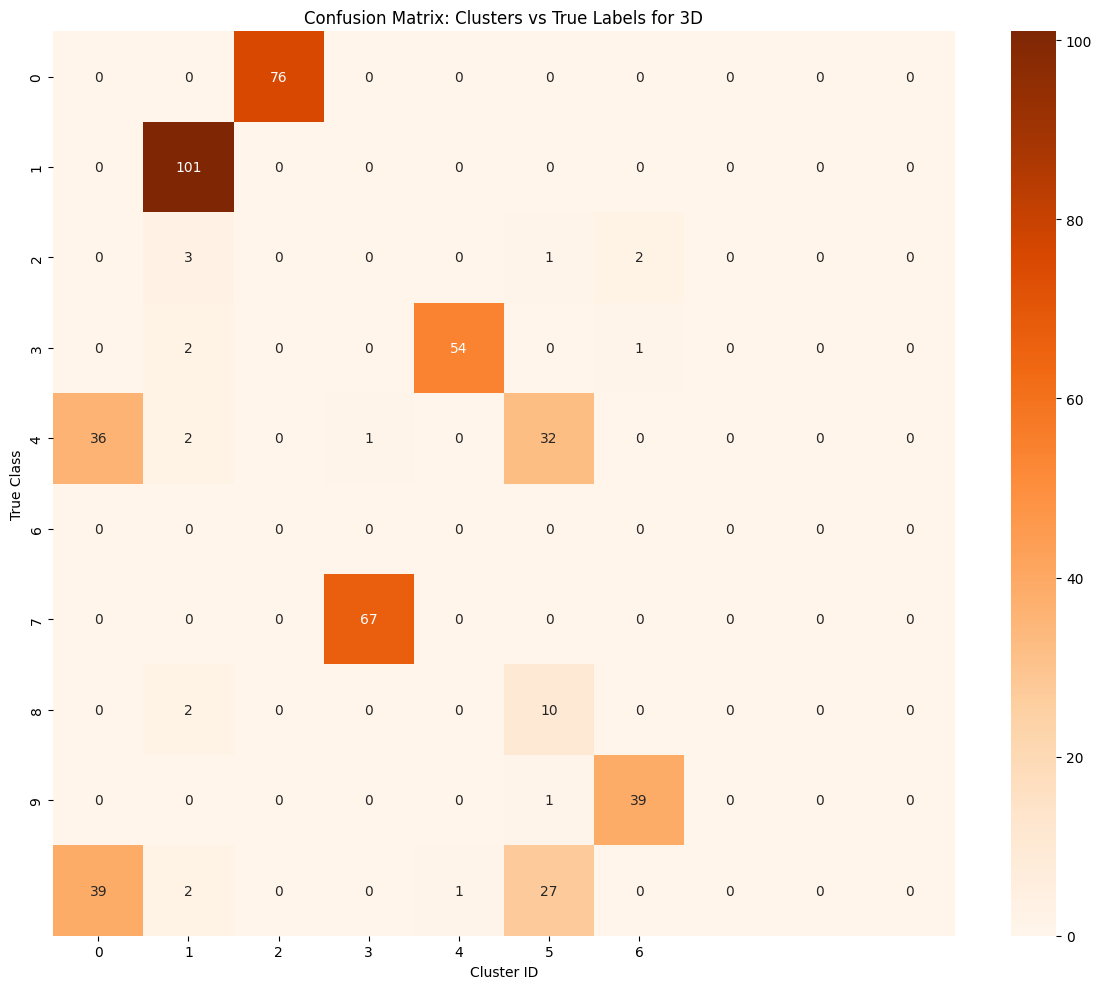

Adjusted Rand Index: 0.767
Normalized Mutual Info: 0.817
Number of clusters: 7
Noise points: 501
Running DBSCAN on 5D t-SNE representation


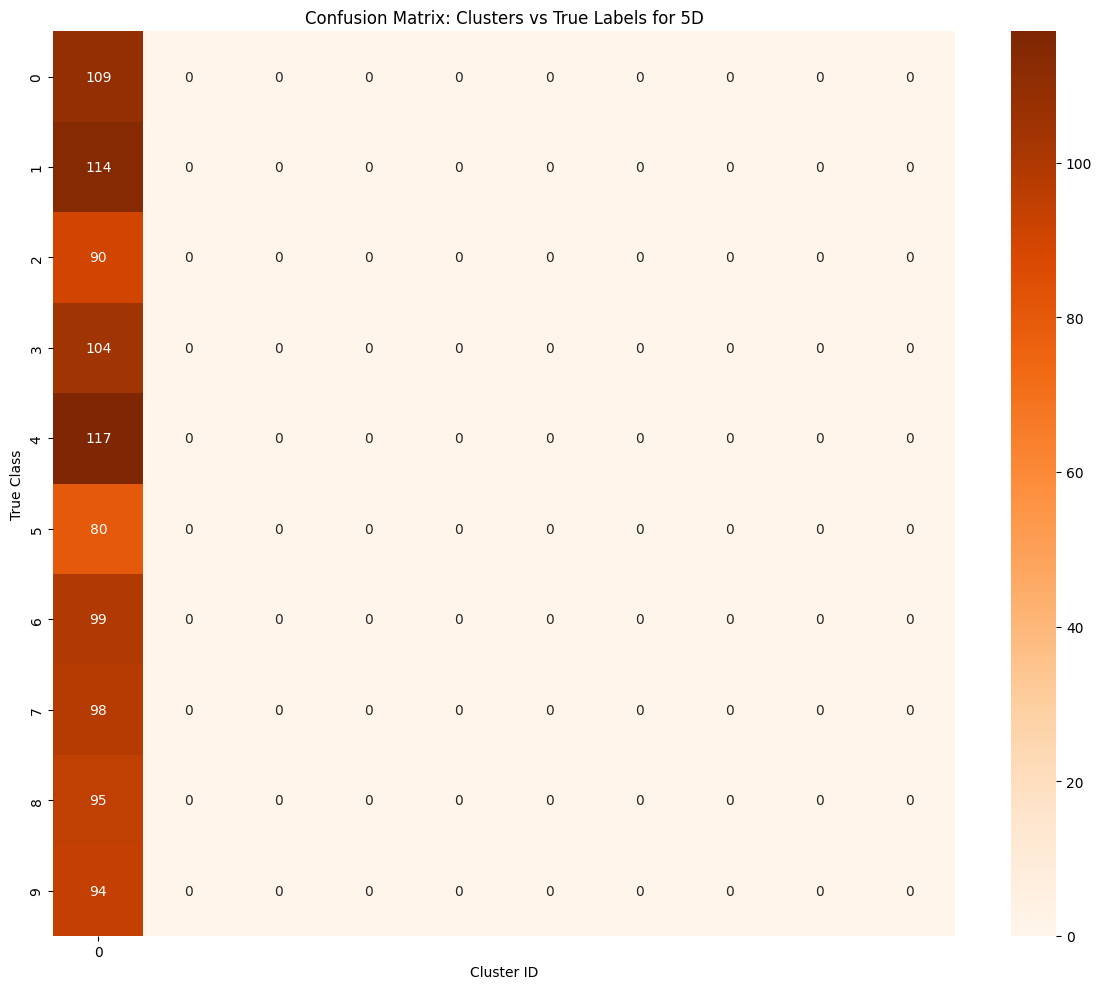

Adjusted Rand Index: 0.000
Normalized Mutual Info: 0.000
Number of clusters: 1
Noise points: 0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score

def load_mnist(n_samples=3000):
    """Load MNIST dataset with subsampling"""
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X, y = mnist.data, mnist.target.astype(int)

    np.random.seed(36)
    indices = np.random.choice(len(X), n_samples, replace=False)
    return X[indices], y[indices]

def preprocess_data(X, n_components=60):
    """Dimensionality reduction using PCA"""
    pca = PCA(n_components=n_components, random_state=36)
    return pca.fit_transform(X)

def apply_tsne(X, n_components=2):
    """t-SNE for visualization"""
    method = "barnes_hut" if n_components <= 3 else "exact"
    perplexity = 40 if n_components <= 3 else 30  # Reduce perplexity for higher dimensions
    tsne = TSNE(n_components=n_components,
                perplexity=perplexity,
                max_iter=2000,  # Increase iterations for stability
                method=method,
                random_state=36)
    X_tsne = tsne.fit_transform(X)

    if np.isnan(X_tsne).any():
        raise ValueError("t-SNE produced NaN values. Try reducing perplexity or increasing iterations.")

    return X_tsne

def perform_dbscan(X, eps=4.5, min_samples=33):
    """DBSCAN clustering"""
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    return dbscan.fit_predict(X)

def plot_confusion_matrix(y_true, cluster_labels, dimension):
    """Plot confusion matrix between true labels and cluster assignments"""
    valid_idx = cluster_labels != -1
    y_filtered = y_true[valid_idx]
    labels_filtered = cluster_labels[valid_idx]

    if len(labels_filtered) == 0:
        print(f"No valid clusters found for {dimension}D t-SNE.")
        return

    conf_matrix = confusion_matrix(y_filtered, labels_filtered)

    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges",
                xticklabels=np.unique(labels_filtered),
                yticklabels=np.unique(y_filtered))
    plt.xlabel("Cluster ID")
    plt.ylabel("True Class")
    plt.title(f"Confusion Matrix: Clusters vs True Labels for {dimension}D")
    plt.tight_layout()
    plt.show()

def run_dbscan_on_tsne(dimension):
    """Pipeline to run DBSCAN on t-SNE transformed MNIST"""
    X, y = load_mnist(n_samples=1000)
    X_pca = preprocess_data(X)
    X_tsne = apply_tsne(X_pca, n_components=dimension)

    labels = perform_dbscan(X_tsne, eps=4.5, min_samples=33)

    plot_confusion_matrix(y, labels, dimension)

    valid_idx = labels != -1
    print(f"Adjusted Rand Index: {adjusted_rand_score(y[valid_idx], labels[valid_idx]):.3f}")
    print(f"Normalized Mutual Info: {normalized_mutual_info_score(y[valid_idx], labels[valid_idx]):.3f}")
    print(f"Number of clusters: {len(np.unique(labels[valid_idx]))}")
    print(f"Noise points: {np.sum(labels == -1)}")

# Run DBSCAN on t-SNE with different dimensions
for dim in [2, 3, 5]:
    print(f"Running DBSCAN on {dim}D t-SNE representation")
    try:
        run_dbscan_on_tsne(dim)
    except ValueError as e:
        print(f"Error encountered for {dim}D: {e}")


## PROBLEM 2: Implement t-SNE dim reduction, run on MNIST dataset.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load MNIST data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data.astype('float32'), mnist.target.astype('int')

# Sample 5000 instances
np.random.seed(42)
indices = np.random.permutation(len(X))[:5000]
X, y = X[indices], y[indices]

# Preprocess: scale to 0-1 and zero-mean
X_scaled = X / 255.0
X_scaled -= X_scaled.mean(axis=0)

# Apply PCA to 50 dimensions
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)
N = X_pca.shape[0]

# Compute squared Euclidean distances
X_sq = np.sum(X_pca ** 2, axis=1)
D = X_sq[:, None] + X_sq[None, :] - 2 * np.dot(X_pca, X_pca.T)
D = np.maximum(D, 0.0)  # Avoid negative due to numerical errors

# Compute P matrix with binary search for beta_i per row
P = np.zeros((N, N))
beta = np.zeros(N)
log2_30 = np.log2(30)

for i in range(N):
    Di = D[i, :].copy()
    Di[i] = 0.0  # Exclude self-distance
    beta_i, trials = 0.6, 0
    betamin, betamax = -np.inf, np.inf
    H_diff = 1.0

    while abs(H_diff) > 1e-5 and trials < 50:
        P_i = np.exp(-Di * beta_i)
        P_i[i] = 0.0  # Set diagonal to zero
        sum_Pi = P_i.sum()
        if sum_Pi == 0:
            P_i = np.ones(N)
            P_i[i] = 0.0
            sum_Pi = N - 1
        P_i /= sum_Pi

        # Compute entropy
        H = -np.sum(P_i * np.log2(P_i + 1e-12))
        H_diff = H - log2_30

        # Adjust beta
        if H_diff > 0:
            betamin = beta_i
            if betamax == np.inf:
                beta_i *= 2
            else:
                beta_i = (beta_i + betamax) / 2
        else:
            betamax = beta_i
            if betamin == -np.inf:
                beta_i /= 2
            else:
                beta_i = (betamin + beta_i) / 2
        trials += 1

    beta[i] = beta_i
    P[i, :] = P_i

# Symmetrize and normalize P
np.fill_diagonal(P, 0.0)
P = (P + P.T) / 2
P /= P.sum()

# Constants for t-SNE
no_dims = 2
max_iter = 100
epsilon = 100
min_gain = 0.01
momentum = True
ConstKL = np.sum(P * np.log(P + 1e-12))

# Initialize variables for t-SNE
Y = 0.0001 * np.random.randn(N, no_dims)
Y_incs = np.zeros_like(Y)
gains = np.ones_like(Y)

for iter in range(max_iter):
    # Compute Q matrix (Student t-distribution)
    sum_Y = np.sum(Y ** 2, axis=1)
    Qnum = 1 / (1 + sum_Y[:, None] + sum_Y[None, :] - 2 * Y.dot(Y.T))
    np.fill_diagonal(Qnum, 0.0)
    Q = Qnum / Qnum.sum()

    # Compute gradient
    L = (P - Q) * Qnum
    Y_grad = 4 * (np.diag(L.sum(axis=1)) - L).dot(Y)

    # Update gains with momentum
    if momentum:
        gains = np.where(np.sign(Y_grad) != np.sign(Y_incs), gains + 0.2, gains * 0.8)
        gains = np.clip(gains, min_gain, None)
        Y_incs = -epsilon * gains * Y_grad
    else:
        Y_incs = -epsilon * Y_grad

    Y += Y_incs
    Y -= Y.mean(axis=0)  # Recenter

    # Print and plot every 10 iterations
    if iter % 10 == 0:
        cost = ConstKL - np.sum(P * np.log(Q + 1e-12))
        print(f"Iteration {iter}: Cost = {cost}")
        plt.figure(figsize=(10, 6))
        plt.scatter(Y[:, 0], Y[:, 1], c=y, cmap='Spectral', s=5)
        plt.colorbar()
        plt.title(f't-SNE Iteration {iter}')
        plt.show()

## PROBLEM 3 : Pairwise Feature selection for text

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Load the 20 Newsgroups dataset
categories = ['sci.space', 'rec.autos']  # Example binary classification (adjust as needed)
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

X_train, y_train = newsgroups_train.data, newsgroups_train.target
X_test, y_test = newsgroups_test.data, newsgroups_test.target

# Preprocess and vectorize text (limit to 5000 features for efficiency)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Baseline: Train LinearSVC on all features (HW3A-PB1 equivalent)
baseline_clf = LinearSVC()
baseline_clf.fit(X_train_tfidf, y_train)
y_pred_baseline = baseline_clf.predict(X_test_tfidf)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

# Feature selection with chi2 (top 200 features)
chi2_selector = SelectKBest(chi2, k=200)
X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2 = chi2_selector.transform(X_test_tfidf)

chi2_clf = LinearSVC()
chi2_clf.fit(X_train_chi2, y_train)
y_pred_chi2 = chi2_clf.predict(X_test_chi2)
chi2_accuracy = accuracy_score(y_test, y_pred_chi2)

# Feature selection with mutual information (top 200 features)
mi_selector = SelectKBest(mutual_info_classif, k=200)
X_train_mi = mi_selector.fit_transform(X_train_tfidf, y_train)
X_test_mi = mi_selector.transform(X_test_tfidf)

mi_clf = LinearSVC()
mi_clf.fit(X_train_mi, y_train)
y_pred_mi = mi_clf.predict(X_test_mi)
mi_accuracy = accuracy_score(y_test, y_pred_mi)

# Print results
print(f"Baseline (All Features) Accuracy: {baseline_accuracy:.4f}")
print(f"Chi2 (Top 200 Features) Accuracy: {chi2_accuracy:.4f}")
print(f"MI (Top 200 Features) Accuracy: {mi_accuracy:.4f}")

## PROBLEM 4 : L1 feature selection on text

In [ ]:
# 1. Load the 20NG dataset (we use a subset for speed; remove subset if full dataset is desired)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'talk.politics.misc']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

# Split into training and test sets
X_train_text, X_test_text, y_train, y_test = train_test_split(newsgroups.data, newsgroups.target, test_size=0.3, random_state=42)

# 2. Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# 3. Train a strongly L1-regularized logistic regression model
# Using a small value of C (e.g., 0.1) for strong regularization. The 'liblinear' solver supports L1 penalty.
clf = LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

# 4. Get coefficients and select top 200 features based on absolute value.
# For multi-class problems, we can sum the absolute coefficients over classes.
# Note: clf.coef_ is of shape (n_classes, n_features)
coef_abs_sum = np.sum(np.abs(clf.coef_), axis=0)
top_200_indices = np.argsort(coef_abs_sum)[-200:]

# Get feature names corresponding to these indices
feature_names = np.array(vectorizer.get_feature_names_out())
selected_features = feature_names[top_200_indices]
print("Selected features (top 200):")
print(selected_features)

# 5. Reconstruct the dataset with only the selected features.
# We create a new vectorizer limited to these features. Since we already have the original TF-IDF matrices,
# we can simply slice the matrices to include only the selected feature columns.
X_train_reduced = X_train[:, top_200_indices]
X_test_reduced = X_test[:, top_200_indices]

# 6. Rerun a classification task on the reduced dataset.
# Here we retrain a logistic regression classifier on the reduced dataset.
clf_reduced = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
clf_reduced.fit(X_train_reduced, y_train)
y_pred = clf_reduced.predict(X_test_reduced)

# 7. Evaluate the model performance on the reduced feature set.
print("\nClassification Report on Reduced Feature Set:")
print(classification_report(y_test, y_pred))
